In [1]:
from IPython.display import Image

#  영역분할

### 영역분할이란?
- 일반적으로는 물체가 이미지에서 차지하는 화소를 구분해 내는 방법
- 물체는 일반적으로 연결되어 있으므로 **영역**분할

### 고전적 영역 분할 vs 의미 분할 

- 물체에 대한 특성 모델이 없이 이미지 상태 (화소값과 주변화소와의 관계)만을 고려하여 분할
- 시벡틱(의미) 분할 (Sematic): 정해진 물체의 특성 정보를 바탕으로 해당 화소를 분류하는 방식을 사용하는 분할 (딥러닝에서 주로 사용)
- **고찰** 고전적 분할 방식이 크게 성공을 못했던 이유가 시멘틱 분할의 개념을 사용하지 않은 부분이라고 생각됨.

## 1. 배경이 단순한 이미지의 영상 분할 

- 예: 스캔한 책 영상 또는 컨베이어 벨트 위를 흐르는 물체의 영상

- **배경**과 **(여러개의) 전경**으로 분류하는 방식을 사용
    
    - 이진화 알고리즘 (여러 임계값을 사용하는 오츄 알고리즘, 군집화 알고리즘 등) 적용
    
    
    - **주의** 여러개의 이진화를 사용한다고 해서 하나의 물체와 배경으로 분리되는 것은 아님. 

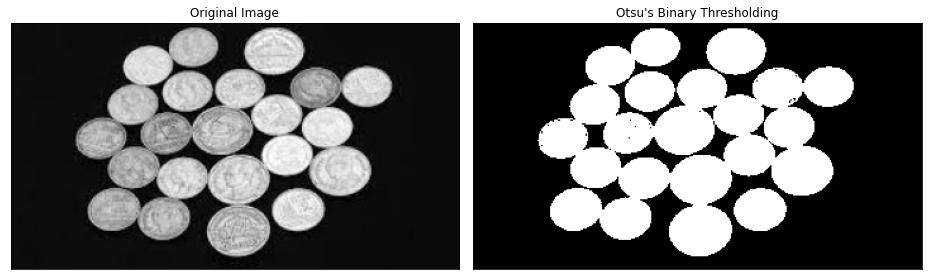

In [2]:
Image("coins_segmentation.png", width=720)

 # 워터셰드 알고리즘
    
 - 명암을 기준으로 지형으로 간주하여, 물이 차면 올라와서 만나는 경계를 영역으로 사용
 - 이진화에 비하여 물체 내부적인 화소 변화에 덜 민감
 - 비슷한 수준의 변화가 심한 영역에서 작은 단위로 분할되는 단점이 있음 
 

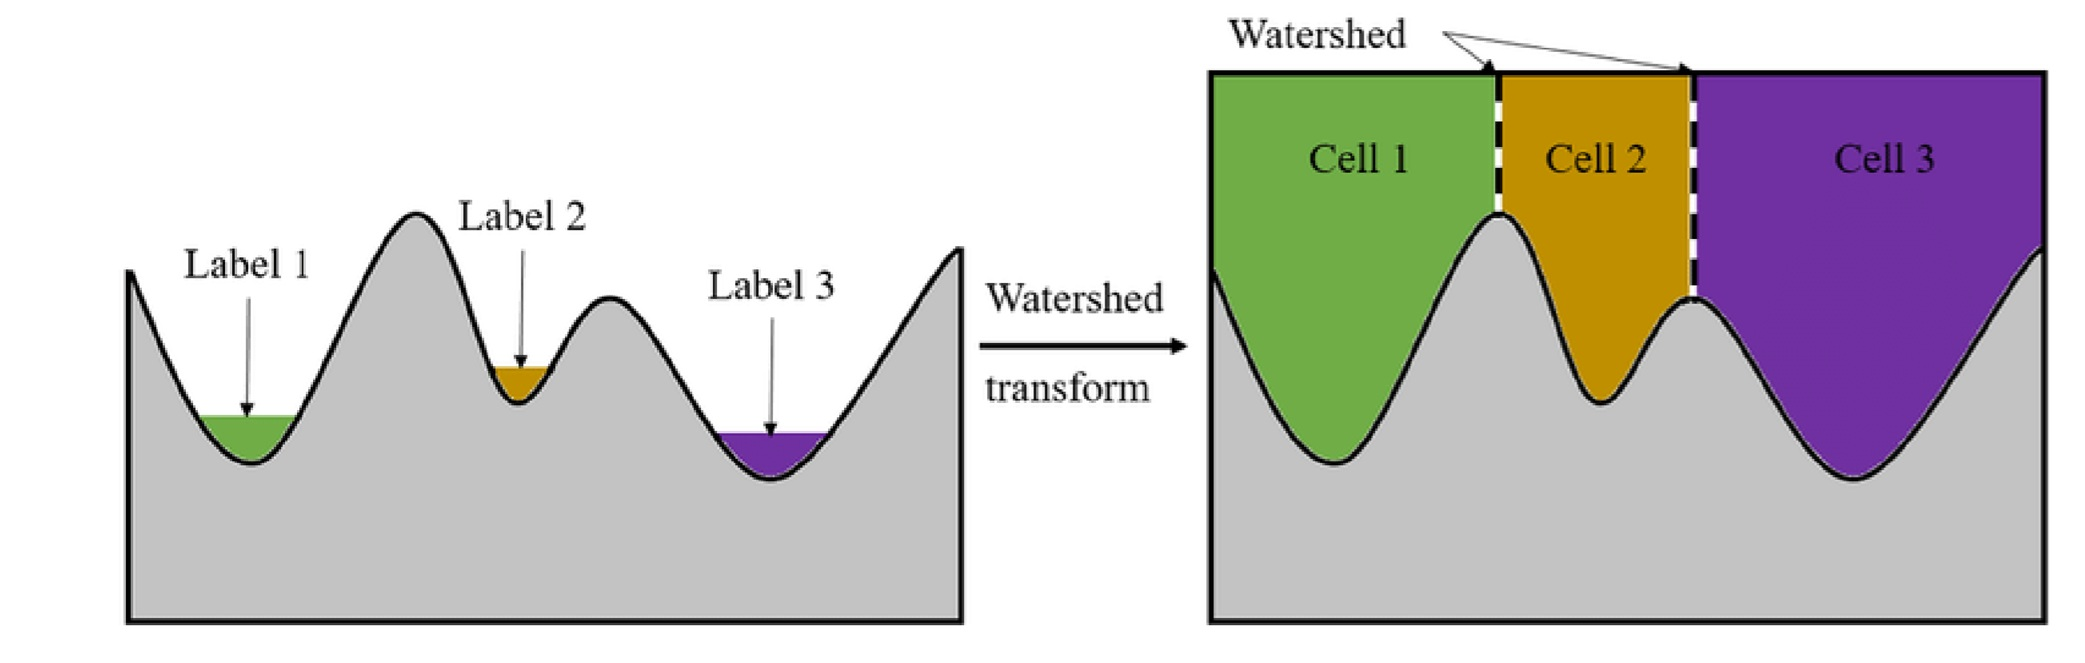

In [3]:
Image("watershed.jpg", width=720)

### OpenCV Watershed 알고리즘

- 사실 OpenCV에서는 classical Watershed 방식을 제공하지 않음.
- marker 기반 watershed 방식을 제공
   - 기본 방식은 매우 작은 세그먼트들이 형성됨.

#### Marker 기반 Watershed 방식 

- 미리 Label링 중심점을 Seed로 제공 (다른 전처리를 통하여)
- Watershed 알고리즘을 적용하여 Label을 확장하는 방식을 사용  
- OpenCV 공식 싸이트를 참고하기 바람 (다소 복잡한 과정이 있어, 시간상 이번 강의에서는 생략)

-  cv2.watershed(img, markers )
    - markers : 0 값은 정해지지 않은 영역, 1 이상의 값(라벨)이 채워진 곳이 seed marker 영역. 

## 2. 슈퍼 화소 분할 

- 이진화 방식의 한계점
    - 의미적인 (사람들이 인식하는) 하나의 물체에 화소의 특성이 균질 (통계학적으로) 균질 하지 않음 
    - 하나의 물체가 여러개의 영역으로 분할 됨. 

- 슈퍼 화소 분할 
    - 화소보다 크지만 물체보다 작은 자잘한 영역으로 과잉 분할
    - 이후에 후처리를 이용하여 통합을 수행 하거나 큰 단위 사용의 편리성을 활용.
   
- SLIC (simple linear iterative clustering) 알고리즘
    -  SOTA (State of the art): 이 분야의 현재 가장 발전된 알고리즘 
    -  알고리즘 간략 설명 
        - Kmean 클러스터링에 기반
        - 격자형태로 초기 중심점을 정의
        - 화소들을 거리를 계산 (x, y, r, g. b) 를 사용하여 가장 가까운 중심에 할당.
        - 할당결과를 바탕으로 중심점을 재계산
        - 이과정을 반복 (iteration)
        

### Slic in OpenCV 
-  이 기능은 opencv-contrib-python패키지가 사용하기 때문에 설치되 있어야한다. 

In [4]:
!pip install opencv-contrib-python 

-  알고리즘 객체 생성 (파라메터)
   slic = cv2.ximgproc.createSuperpixelSLIC(image, algorithm, region_size, ruler)

- 실행 
  slic.iterate(n)

In [5]:
import cv2
import numpy as np

# 1. 이미지 로드 및 변환
img = cv2.imread('slic_input.png')
# SLIC는 보통 CIELAB 색 공간에서 가장 잘 작동합니다.
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

# 2. SLIC 객체 생성
# region_size: 슈퍼픽셀의 대략적인 크기 (작을수록 세밀함)
# ruler: 컴팩트함 계수 (값이 클수록 정사각형 형태에 가까워짐)
slic = cv2.ximgproc.createSuperpixelSLIC(lab, algorithm=cv2.ximgproc.SLIC, 
                                         region_size=30, ruler=10.0)

# 3. 알고리즘 실행 (반복 횟수 지정)
slic.iterate(10)

# 4. 결과 가져오기
labels = slic.getLabels()        # 각 픽셀이 속한 슈퍼픽셀 번호
number_of_spixels = slic.getNumberOfSuperpixels()

# 5. 경계선 시각화
mask = slic.getLabelContourMask() # 경계선 마스크 (255: 경계, 0: 나머지)
result = img.copy()
result[mask == 255] = (0, 0, 0) # 경계선을 녹색으로 표시


plt.figure(figsize=(10, 8))
plt.subplot(1,3,1), plt.imshow(img[:,:,::-1]), plt.title('input'), plt.axis('off') 
plt.subplot(1,3,2), plt.imshow(mask, cmap='gray'), plt.title('mask by rect'), plt.axis('off') 
plt.subplot(1,3,3), plt.imshow(result[:,:,::-1]), plt.title('img by rec'), plt.axis('off')  


NameError: name 'plt' is not defined

## 화소간의 연결성을 고려한 분할 방법 

- 책에서는 최적 분할이라는 제목을 사용하고 있는데 일반적으로 통용되는 표현이 아님.

### 화소간의 연결성을 고려하는 방식 

- 두개의 노드 (화소 또는 슈터픽셀)간의 유사도 또는 거리는 다음과 같이 정의됨
    - 거리 
    
    $d_{pq} = | I(p) - I(q) |, \quad q \in \text{neighbor}(p)$
    
    $\phantom{d_{pq}} = \infty \qquad \text{otherwise}$

    - 유사도
    
   $ s_{p,q} =  D - d_{pq}$  또는   $exp(-d_{pq})$          

### 정규화 절단 (Normalized Cut)

- 이미지를 하나의 영역으로 시작하고.
- 가장 약한 연결을 갖은 두개의 영역으로 쪼개 나감.

     $$ Cut(C1, C2)  = \sum_{p \in C1, q \in C2}  w_{p,q} $$
       
   - 그런데, 이 조건을 사용하면 작은 조각과 큰 조각으로 쪼개지게 됨.
   
   
   - 그래서 이를 크기로 나누어 정규화하게 됨. 이를 식으로 표시하면 다음과 같게됨.
   
      $$ Normalzied Cut(C1, C2)  = \frac{cut(C1,C2)}{Assoc(C1, C)} + \frac{Cut(C1, C2)}{Assoc(C2, C)} $$
      
      여기서  $ Assoc(C_i, C)  = \sum_{p \in C_i, q \in C}  w_{p, q} $, $ C = C_1 \cup C_2 $
      
    - 어느 연결을 끊어낼지는 (모든 경우를 검색하는 것이 아니라) 다음 수학적인 방법으로 해결함.
    
      $$ (D− W) y=λDy $$
      
- OpenCV는 normalized cut을 지원하지 않고 있고 sklearn-image 에서 제공함.
  
     - 이것도 설치되어 있어야함. 
      


In [ ]:
!pip install scikit-image

In [ ]:
from skimage import data, segmentation, color
from skimage import graph
from matplotlib import pyplot as plt

img = data.coffee()

labels1 = segmentation.slic(img, compactness=30, n_segments=400, start_label=1)
out1 = color.label2rgb(labels1, img, kind='avg', bg_label=0)

g = graph.rag_mean_color(img, labels1, mode='similarity')
labels2 = graph.cut_normalized(labels1, g)
out2 = color.label2rgb(labels2, img, kind='avg', bg_label=0)


plt.figure(figsize=(10, 8))
plt.subplot(1,2,1), plt.imshow(img), plt.title('input'), plt.axis('off') 
plt.subplot(1,2,2), plt.imshow(out2), plt.title('normalized cut'), plt.axis('off') 


## 3. 대화식 분할 

- 위와 같이 물체의 모델 정보가 없이 이미지의 화소 정보만을 가지고 분할하는 방식은 일반적인 영상에서 적용이 잘 안됭
- 모델에 대한 정보를 확보하는 방법으로 사용자가 지정해주는 방법이 등장 
- 대표적인 알고리즘으로 Graphcut 과  Active Contour 방식이 있음
   - Active contour 는 OpenCV에서 제공이 안됨.

### Graph cut 

- 이미지의 화소 또는 슈퍼 픽셀을 그래프의 노드로 정의하고, 노드간의 유사도를 에지의 값으로 정의함.
- 그래프 컷 알고리즘 개념 

    - 두개의 기준 노드 (source 와 sink 라고도 함)를 중심으로 그래프를 둘로 나눔.
    - 가능한 **종합적인** 약한 연결이 끊어지도록 함.
        - 단순히 바로 옆 화소와의 연결 정도만을 고려하는 것이 아니라, 기준 노드까지 연결정도를 고려함.
        
- Maxflow, Mincut 알고리즘

    - 그래프 이론 중의 하나로 그래프에서 하나의 노드를 물 유입의 소스로  하나를 싱크로 정의
    - 각 유사도를 물이 흐를 수있는 최대 유량으로 정의 
    - 최대의 물이 흐를수 있는 물의 양 (Maxflow)을 계산하는 알고리즘 
    - 이때 가능한 유량이 모두 사용된 연결들을 모으면 Min-Cut 이됨.
       - 참고:  https://youtu.be/CQ2jSOGLrSQ?si=oNNJQSJzMPiEPIts
       - 참고:  https://youtu.be/YMME2Xaqnq8?si=Ub8TTciESj3EgNQk
    - 매우 응용이 많은 알고리즘으로 한동안 고속 처리를 하기 위한 방안이 연구가 됨.

In [ ]:
Image("Max_flow.svg.png", width=640)

### Grabcut 

- **사용자**가 두개의 영역으로 나눌 source 와 target 화소들 선택하게 함.  
- 각 이웃화소들을 화소유사도로 연결하고  
- 선택된 화소들의 히스토그램을 바탕으로 각 화소들과의 유사도를 계산하여 의 추가적인 연결을 구성 
- **그래프컷** 알고리즘을 사용하여 두개의 영역으로 분할 

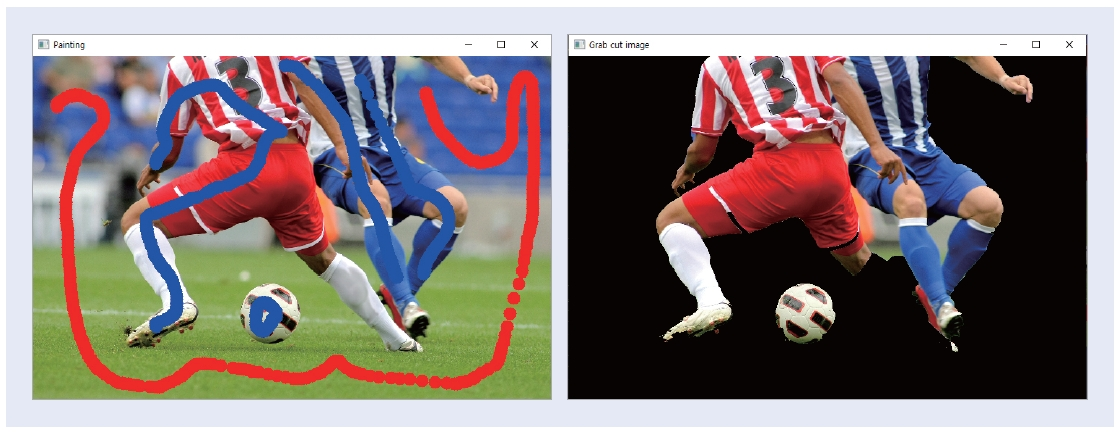

In [6]:
Image("프로그램 4-7_실행결과.jpg", width=720)

### OpenCV Graphcut 사용법 

- mask, bgdModel, fgdModel = cv.**grabCut**(img, mask, rect, bgdModel, fgdModel, iterCount, mode)
    - mode
        - cv2.GC_INIT_WITH_RECT  (사각형 내부는 FC, 외부는 BG로 초기화)
        - cv2.GC_INIT_WITH_MASK (주어진 마스크를 사용하여 FG/BG 초기화)
    - mask
        - cv.GC_BGD ( 확실한 배경, 0)
        - cv.GC_FGD (확실한 전경, 1), 
        - cv.GC_PR_BGD (아마도 배경, 2) 
        - cv.GC_PR_FGD (아마도 전경, 3)
    - bgdModel fgdModel:
        - 내부적으로 사용하는 GMM histogram 모델 저장용 공간 
        - 리턴하는 이유는 반복호출을 가능하게 하기 위함

### cv2.GC_INIT_WITH_RECT

- RECT 밖은 BGD, 안쪽은 PR_FGD
- 이미지에서 전경이 포함되는 영역을 사각형 안에는 전경이 모두 포함되어 있어야 함 

(<Axes: title={'center': 'img by rec'}>,
 Text(0.5, 1.0, 'img by rec'),
 (-0.5, 547.5, 341.5, -0.5))

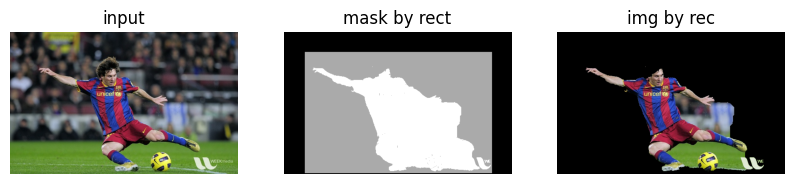

In [7]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
 
img = cv2.imread('messi5.jpg')
mask = np.zeros(img.shape[:2],np.uint8)
 
bgdModel = np.zeros((1,65),np.float64) #GMM   5* 13 = 65,  3/*mean*/ + 9/*covariance*/ + 1/*component weight
fgdModel = np.zeros((1,65),np.float64)  

# 1. GC_INIT_WITH_RECT   
# 첫번째는 이미지에서 전경이 포함되는 영역을 사각형으로 대략적으로 지정합니다.
# 단, 이때 지정한 사각형 영역 안에는 전경이 모두 포함되어 있어야 합니다. 
rect = (50,50,450,290)

cv2.grabCut(img,mask,rect,bgdModel,fgdModel,1,cv2.GC_INIT_WITH_RECT)  # BG, PRBFG
img_seg1 = img*np.where((mask==2)|(mask==0),0,1).astype('uint8')[:,:, np.newaxis]  # 배경(0,2)=>0,전경(1,3)=>1로 하고, hxw => hxwx1 차원변환 

plt.figure(figsize=(10, 8))
plt.subplot(1,3,1), plt.imshow(img[:,:,::-1]), plt.title('input'), plt.axis('off') 
plt.subplot(1,3,2), plt.imshow(mask, cmap='gray'), plt.title('mask by rect'), plt.axis('off') 
plt.subplot(1,3,3), plt.imshow(img_seg1[:,:,::-1]), plt.title('img by rec'), plt.axis('off')  


###  cv2.GC_INIT_WITH_MASK 
 
 - 주어진 마스크를 사용하여 FG/BG 초기화
 - 좀 더 정교한 제어가 가능 
 - 다음 예는 RECT 과 Mask 를 합친 예

(<Axes: title={'center': 'final'}>,
 Text(0.5, 1.0, 'final'),
 (-0.5, 547.5, 341.5, -0.5))

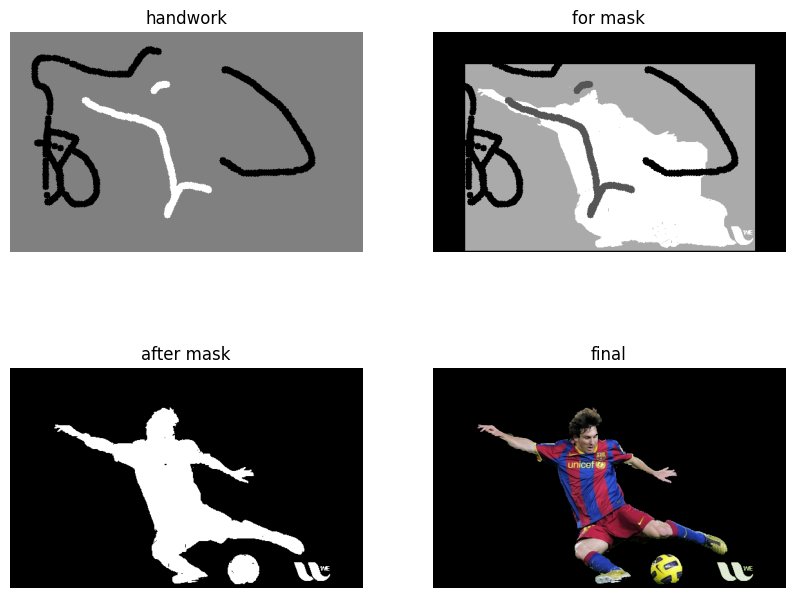

In [8]:
# Step 2
# 2. GC_INIT_WITH_MASK
# 그리고 두번째는 첫번째에서 얻어진 전경 이미지의 내용중 포함되어진 배경 부분은 어디인지, 
# 누락된 전경 부분은 어디인지를 마킹하면 이를 이용해 다시 전경 이미지가 새롭게 추출됩니다.
img_mask = cv2.imread('mask.png',0)  # 0 => 0 (BGD), 255=> 1 (FGD)
mask[img_mask == 0] = 0  
mask[img_mask == 255] = 1
mask_before = mask.copy()  # for debugging

cv2.grabCut(img,mask,None,bgdModel,fgdModel,1,cv2.GC_INIT_WITH_MASK)

mask_binary = np.where((mask==2)|(mask==0),0,1).astype('uint8')

img_seg2 = img*mask_binary[:,:,np.newaxis]

plt.figure(figsize=(10, 8))
plt.subplot(2,2,1), plt.imshow(img_mask, cmap='gray'), plt.title('handwork'), plt.axis('off') 
plt.subplot(2,2,2), plt.imshow(mask_before, cmap='gray'), plt.title('for mask'), plt.axis('off') 
plt.subplot(2,2,3), plt.imshow(mask_binary, cmap='gray'), plt.title('after mask'), plt.axis('off') 
plt.subplot(2,2,4), plt.imshow(img_seg2[:,:,::-1]), plt.title('final'),  plt.axis('off') 



### Active contour 

- 대상 물체의 주변을 사용자가 대략의 폐곡선 $C$을 지정
- 이 패곡선의 위치가 물체의 경계가 되었을때  최소가 되는 목적함수를 정의 

    $$ min_{C} (E_{image} (C) + E_{internal}(C) +  E_{constraints}(C))$$
    
     - 개념 적으로만 설명 (굴곡이있는 영역에 적당히 느슨한 탁력을 갖는 고무줄이 노여있다고 생각) 
     - $ E_{image} (C) $ : contour가 물체의 경계 에지에 있을때 값이 낫도록 하는 함수를 정의 
     - $ E_{internal}(C)$ : contour가 가능한 smooth 하도록 정의 (curveture 가 작도록)
     - $ E_{constraints}(C))$ : 사용자가 정의하는 추가적인 요구사항을 만족하도록 정의 
     
- 반복적으로 $C$를 업데이트하는 모양이 뱀이 또아리를 트는 것 같다고 해서 Snake 알고리즘이라고도 함.     
    



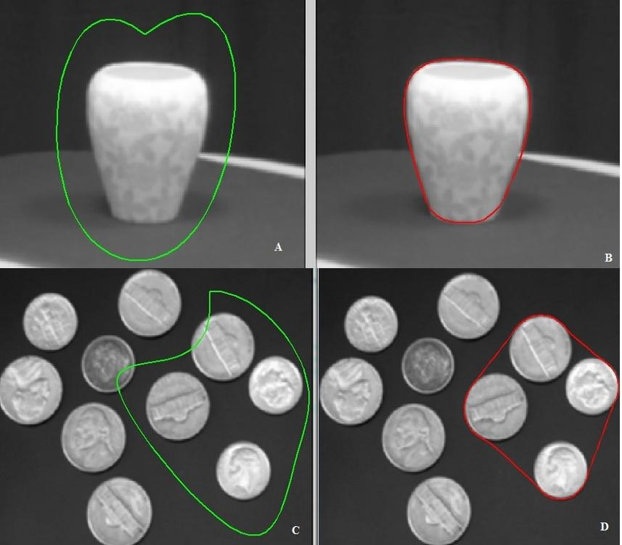

In [9]:
Image("activecontour.png", width=480)

### 4. 영역특성 


### 1) 영역 경계 추출 및 표현 

- 영역분할에의하여 얻어진 영역의 형태를 대표하는 값으로 뽑아내어 비교에 활용 

- 영역의 경계 추출 
    - 경계 화소의 8개의 방향의 연속으로 표시 가능 함

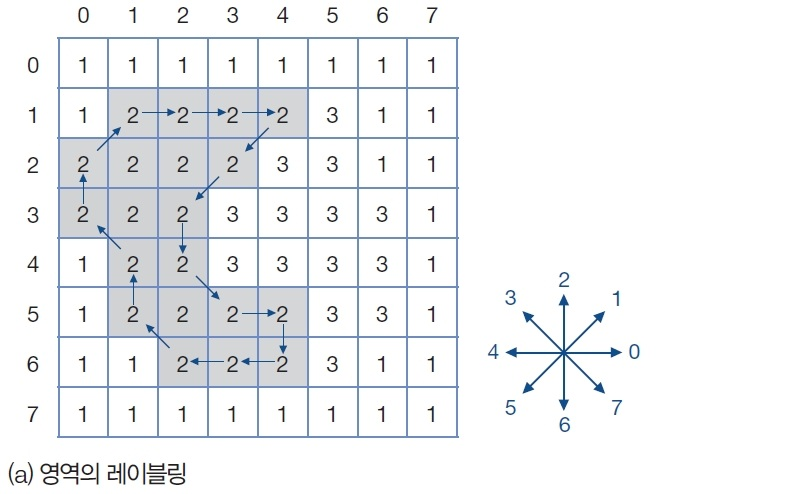

In [10]:
Image("boundary_description.jpg", width=480)

### 영역의 특성 

#### - 영역특성의 예 
    - 면적
    - 둘레 길이 
    - 둥근 정도 vs 길쭉한 정
    - 분산
    - 주축의 방향 

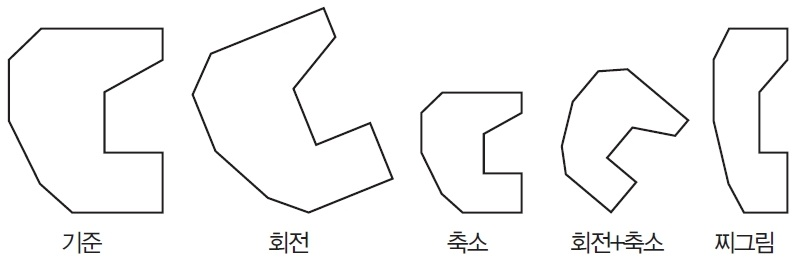

In [11]:
Image("region_distortion.jpg", width=640)

###  특징의 불변성과 등변성
    
- 변환을 해도 값이 변하지 않으면 불변성invariant이 있는 특징
    - 예) 면적은 회전에 불변이지만 축소에는 불변이 아님. 주축은 회전에 불변이 아니지만 축소에는 불변
    - 예) 면적은 축소에 등변이지만 회전에는 등변이 아님
 
- 과업에 따라 특징을 선택하는 일이 중요
     예) 로봇이 물체를 인식한 다음 물체를 집어야 한다면 회전에 등변인 특징을 사용해야 함

#### Hu-moment 


- 모먼트 
$$ m_{q,p}  = \sum_{R} y^q x^p  $$
  
- 중심모먼트 (이동 불변)
$$ \mu_{q,p}  = \sum_{R} (y-m_{1,0})^q (x - m_{0,1})^p  $$

- 크기 불변 모먼트 
$$\begin{aligned}
&\eta_{qp} = \frac{\mu_{qp}}{\mu_{00}^{(q+p)/2 + 1}}  \text{where } q+p \ge 2
\end{aligned}$$

- 이를 이용하여 Hu 라는 사람이 회번 불면한 7가지 값을 정의함 

$$\begin{aligned}
&h_1 = \eta_{20} + \eta_{02} \\
&h_2 = (\eta_{20} - \eta_{02})^2 + 4\eta_{11}^2 \\
&h_3 = (\eta_{30} - 3\eta_{12})^2 + (3\eta_{21} - \eta_{03})^2 \\
&h_4 = (\eta_{30} + \eta_{12})^2 + (\eta_{21} + \eta_{03})^2 \\
&h_5 = (\eta_{30} - 3\eta_{12})(\eta_{30} + \eta_{12})[ (\eta_{30} + \eta_{12})^2 - 3(\eta_{21} + \eta_{03})^2 ] \\
&\quad + (3\eta_{21} - \eta_{03})(\eta_{21} + \eta_{03})[ 3(\eta_{30} + \eta_{12})^2 - (\eta_{21} + \eta_{03})^2 ] \\
&h_6 = (\eta_{20} - \eta_{02})[ (\eta_{30} + \eta_{12})^2 - (\eta_{21} + \eta_{03})^2 ] + 4\eta_{11}(\eta_{30} + \eta_{12})(\eta_{21} + \eta_{03}) \\
&h_7 = (3\eta_{21} - \eta_{03})(\eta_{30} + \eta_{12})[ (\eta_{30} + \eta_{12})^2 - 3(\eta_{21} + \eta_{03})^2 ] \\
&\quad - (\eta_{30} - 3\eta_{12})(\eta_{21} + \eta_{03})[ 3(\eta_{30} + \eta_{12})^2 - (\eta_{21} + \eta_{03})^2 ]
\end{aligned}$$


 
 


### Hu-moment 사용법 

In [12]:
#  1. 이진화 (정확한 모멘트 계산을 위해 권장)
# mask_binary  #  GC 에서 
# 2.  중심 모멘트(Central Moments) 계산
moments = cv2.moments(mask_binary)
print(moments)
# 3. Hu-Moments 계산 (7개의 불변 특징량 추출)
hu_moments = cv2.HuMoments(moments)
print(hu_moments)

{'m00': 29646.0, 'm10': 8168157.0, 'm01': 6140501.0, 'm20': 2414162067.0, 'm11': 1790447670.0, 'm02': 1424855475.0, 'm30': 761801429421.0, 'm21': 556987929960.0, 'm12': 433642656646.0, 'm03': 358210043843.0, 'mu20': 163646355.71857923, 'mu11': 98597969.3099575, 'mu02': 152989033.28776225, 'mu30': 6467386424.476831, 'mu21': 2616616022.693243, 'mu12': 217402635.30372664, 'mu03': -293130038.06485534, 'nu20': 0.1861976218505615, 'nu11': 0.11218525047010515, 'nu02': 0.17407166839929575, 'nu30': 0.04273793655469091, 'nu21': 0.017291184139333022, 'nu12': 0.0014366452573900256, 'nu03': -0.001937068878655002}
[[ 3.60269290e-01]
 [ 5.04891604e-02]
 [ 4.37229421e-03]
 [ 2.18714253e-03]
 [ 6.75402059e-06]
 [ 3.25167628e-04]
 [-3.57617599e-07]]


### 끝